# Higher-resolution sea ice concentration information


In [1]:
import xarray as xr
import rioxarray
import numpy as np
import rasterio as rio
import skimage
import skimage.io as io
import ultraplot as uplt
import pyproj
import os
import pandas as pd


# To-do items: 
- Download just the landmask tiff for all 9 full regions
- Generate updated sea ice fraction
- NSIDC CDR for gap years

In [3]:
cases_100km = pd.read_csv('../data/metadata/validation-region-case-100km.csv')
cases_250km = pd.read_csv('../data/metadata/validation-region-case-100km.csv')
cases_500km = pd.read_csv('../data/metadata/validation-region-case-500km.csv')

sic_dataloc = '/Users/dwatkin2/Documents/research/data/ASI_SIC/'
modis_dataloc = '../data/modis/'
asi_dataloc = '../data/asi_sic/'
scale = 500

In [4]:
region_cases = {region: data for region, data in cases_500km.groupby('region_name')}


The ASI sea ice concentration data has two sections: AMSR2 and AMSRE, with slightly different file strings.

In [41]:
def get_asi_sic_filenames(year, dataloc):
    if os.path.exists(os.path.join(dataloc, 'asi-AMSR2-n6250-{y}'.format(y=year))):
        year_dir = 'asi-AMSR2-n6250-{y}'.format(y=year)
    elif os.path.exists(os.path.join(dataloc, 'asi-AMSRE-n6250-{y}'.format(y=year))):
        year_dir = 'asi-AMSRE-n6250-{y}'.format(y=year)
    else:
        print("Missing " + str(year))
        return
        
    files = os.listdir(os.path.join(dataloc, year_dir))
    files.sort()
    file_paths = [os.path.join(dataloc, year_dir, f) for f in files if f[0] != '.']       
    return file_paths

# Extracting 500 km images for ASI 6.25 km sea ice concentration

In [42]:
for region in region_cases:
    for row, data in region_cases[region].iterrows():
        year = data.start.split('-')[0]
        date = data.start.replace('-', '')
        files = get_asi_sic_filenames(year, sic_dataloc)
        try:
            file = next(f for f in files if date in f)
            
            
            fname = '{cn}-{rg}-{dx}km-{date}.{satellite}.{imtype}.{scale}.tiff'.format(
                            cn=str(data.case_number).zfill(3),
                            rg=data.region_name,
                            dx=scale,
                            imtype='truecolor',
                            date=data.start.replace('-', ''),
                            satellite='aqua',
                            scale='250m'
                        )
            ref_img = rio.open(os.path.join(modis_dataloc, 'truecolor', fname))
            lm = (ref_img.read() > 0)[0, :, :]
            left, bottom, right, top = ref_img.bounds
            n, m = ref_img.shape
            X = np.linspace(left, right, m)
            Y = np.linspace(bottom, top, n)
            
            with xr.open_dataset(file, decode_coords="all") as ds_asi:
                # reproject onto the 3413 grid
                ds_ = ds_asi.rio.reproject("EPSG:3413")
                dx = 10000 # buffer for edges
                
                # select region
                asi_sel = ds_.sel(x=slice(left - dx, right + dx), y=slice(top + dx, bottom - dx))
            
                # interpolate
                asi_nearest = asi_sel.interp({'x': X, 'y': Y}, method='nearest')
                ice_mask = (asi_nearest['z'] > 1).astype(np.uint8) * 255
                ice_conc = asi_nearest['z']
            
                # Convert to grayscale levels
                land_mask = np.isnan(ice_conc.data).astype(np.uint8) * 255
                ice_conc_img = (ice_conc.fillna(0).data / 100 * 255).round().astype(np.uint8)
                
                io.imsave(
                    os.path.join(
                        asi_dataloc, 'sea_ice_concentration', fname.split('.')[0] + ".asi.sea_ice_concentration.6250m.png"),
                    ice_conc_img[::-1, :]) 
            
                io.imsave(
                    os.path.join(
                        asi_dataloc, 'landmask', fname.split('.')[0] + ".asi.landmask.6250m.png"),
                    land_mask[::-1, :]) 
        
        except:
            print(date)

20120419
20120422
20120527


/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/027-barents_kara_seas-500km-20130422.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/043-beaufort_sea-500km-20190813.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/044-beaufort_sea-500km-20200808.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/045-beaufort_sea-500km-20170925.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-package

20120607


/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/072-bering_chukchi_seas-500km-20080418.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)


20120513
20120523


...

20120623
20120404


/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/118-greenland_sea-500km-20150430.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/119-greenland_sea-500km-20220723.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/120-greenland_sea-500km-20090309.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/122-greenland_sea-500km-20070327.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)


20120406


/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/123-greenland_sea-500km-20150513.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/125-greenland_sea-500km-20130521.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/126-greenland_sea-500km-20090314.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/skimage/_shared/utils.py:386: UserWarning: ../data/asi_sic/landmask/153-laptev_sea-500km-20190816.asi.landmask.6250m.png is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/sk

20120426


In [5]:
missing = {}
imtype = 'sea_ice_concentration'
for region in region_cases:
    missing[region] = []
    for row, data in region_cases[region].iterrows():
        fname = '{cn}-{rg}-{dx}km-{date}.{satellite}.{imtype}.{scale}m.png'.format(
            cn=str(data.case_number).zfill(3),
            rg=region,
            dx=500,
            imtype=imtype,
            date=data.start.replace('-', ''),
            satellite='asi',
            scale=6250
        )
        if not os.path.exists(os.path.join(asi_dataloc, imtype, fname)):
            missing[region].append(fname)
for region in missing:
    print(region, len(missing[region]))

baffin_bay 3
barents_kara_seas 0
beaufort_sea 0
bering_chukchi_seas 3
east_siberian_sea 0
greenland_sea 3
hudson_bay 0
laptev_sea 0
sea_of_okhostk 1


In [6]:
missing

{'baffin_bay': ['003-baffin_bay-500km-20120419.asi.sea_ice_concentration.6250m.png',
  '009-baffin_bay-500km-20120422.asi.sea_ice_concentration.6250m.png',
  '013-baffin_bay-500km-20120527.asi.sea_ice_concentration.6250m.png'],
 'barents_kara_seas': [],
 'beaufort_sea': [],
 'bering_chukchi_seas': ['070-bering_chukchi_seas-500km-20120607.asi.sea_ice_concentration.6250m.png',
  '073-bering_chukchi_seas-500km-20120513.asi.sea_ice_concentration.6250m.png',
  '075-bering_chukchi_seas-500km-20120523.asi.sea_ice_concentration.6250m.png'],
 'east_siberian_sea': [],
 'greenland_sea': ['111-greenland_sea-500km-20120623.asi.sea_ice_concentration.6250m.png',
  '112-greenland_sea-500km-20120404.asi.sea_ice_concentration.6250m.png',
  '121-greenland_sea-500km-20120406.asi.sea_ice_concentration.6250m.png'],
 'hudson_bay': [],
 'laptev_sea': [],
 'sea_of_okhostk': ['189-sea_of_okhostk-500km-20120426.asi.sea_ice_concentration.6250m.png']}

# Extract SIC from NSIDC CDR

In [ ]:
# 3 samples from the Bering-Chukchi Seas fall in the 2012 gap period (May, June)

In [50]:
nsidc_dataloc = '/Users/dwatkin2/Documents/research/data/nsidc_daily_cdr_v6/'
nsidc_saveloc = '../../calval_tgrs/data/validation_dataset/nsidc_500km/'

def get_nsidc_sic_filenames(year, dataloc):
    year_dir = os.path.join(dataloc, str(year))
    if os.path.exists(year_dir):
        files = os.listdir(year_dir)
        files.sort()
        file_paths = [os.path.join(dataloc, year_dir, f) for f in files if f[0] != '.']       
        return file_paths        
    else:
        print("Missing " + str(year))
        return

In [ ]:
for region in region_cases:
    for row, data in region_cases[region].iterrows():
        year = data.start.split('-')[0]
        date = data.start.replace('-', '')
        files = get_nsidc_sic_filenames(year, nsidc_dataloc)
        try:
            file = next(f for f in files if date in f)
                        
            fname = '{cn}-{rg}-{dx}km-{date}.{satellite}.{imtype}.{scale}.tiff'.format(
                        cn=str(data.case_number).zfill(3),
                        rg=data.region_name,
                        dx=scale,
                        imtype='truecolor',
                        date=data.start.replace('-', ''),
                        satellite='aqua',
                        scale='250m'
                    )
            ref_img = rio.open(os.path.join(modis_dataloc, 'truecolor', fname))
            lm = (ref_img.read() > 0)[0, :, :]
            left, bottom, right, top = ref_img.bounds
            n, m = ref_img.shape
            X = np.linspace(left, right, m)
            Y = np.linspace(bottom, top, n)

            with xr.open_dataset(file, decode_coords="all") as ds_nsidc:
                ds_ = ds_nsidc.rio.reproject("EPSG:3413")
                dx = 30000 # buffer for edges - needs to be larger than grid cell
                
                # select region
                nsidc_sel = ds_.sel(x=slice(left - dx, right + dx), y=slice(top + dx, bottom - dx))
                
                # interpolate
                nsidc_nearest = nsidc_sel.interp({'x': X, 'y': Y}, method='nearest')
                ice_mask = (nsidc_nearest['cdr_seaice_conc'].isnull()).astype(np.uint8) * 255
                ice_conc = nsidc_nearest['cdr_seaice_conc']
                
                # Convert to grayscale levels. Squeeze to remove the time dimension.
                land_mask = (np.isnan(ice_conc.data).astype(np.uint8) * 255).squeeze()
                ice_conc_img = (ice_conc.fillna(0).data * 255).round().astype(np.uint8).squeeze()
                
                io.imsave(
                    os.path.join(
                        nsidc_saveloc, 'sea_ice_concentration', fname.split('.')[0] + ".nsidc.sea_ice_concentration.25km.png"),
                    ice_conc_img[::-1, :]) 
                
                io.imsave(
                    os.path.join(
                        nsidc_saveloc, 'landmask', fname.split('.')[0] + ".nsidc.landmask.25km.png"),
                    land_mask[::-1, :]) 
        except:
            print(date)

# Orientation test

In [101]:
fname = '006-baffin_bay-500km-20220530.aqua.truecolor.250m.tiff'
fname = '065-bering_chukchi_seas-500km-20080507.aqua.truecolor.250m.tiff/'
fname = '061-beaufort_sea-500km-20080613.aqua.truecolor.250m.tiff'
tc_img = io.imread(modis_dataloc + 'truecolor/' + fname)
nsidc_sic_img = io.imread(nsidc_saveloc + 'sea_ice_concentration/' + fname.replace('aqua.truecolor.250m.tiff', 'nsidc.sea_ice_concentration.25km.png'))
asi_sic_img = io.imread(asi_dataloc + 'sea_ice_concentration/' + fname.replace('aqua.truecolor.250m.tiff', 'asi.sea_ice_concentration.6250m.png'))

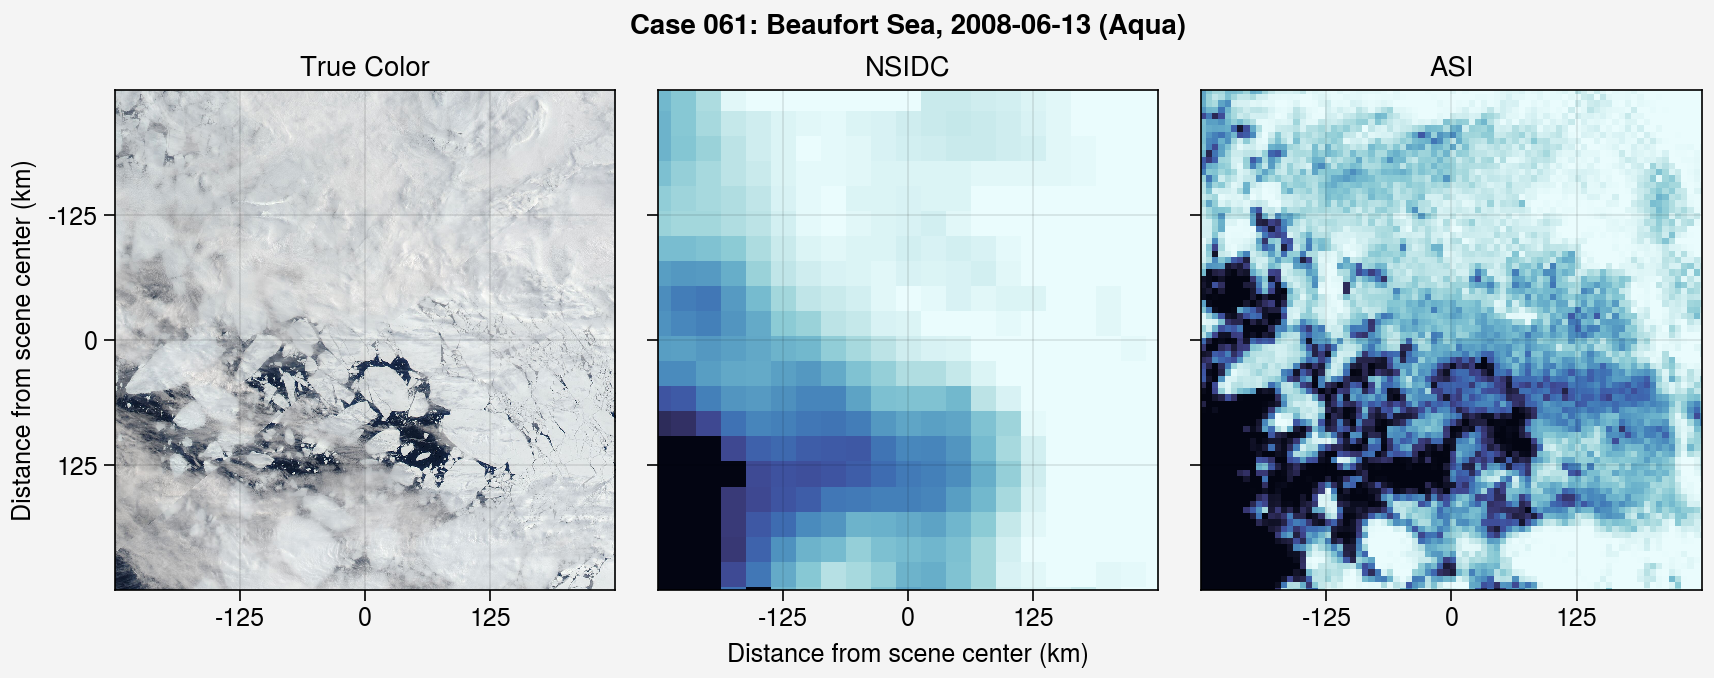

In [102]:
fig, axs = uplt.subplots(ncols=3)
axs[0].imshow(tc_img)
axs[1].imshow(nsidc_sic_img / 255, vmin=0, vmax=1, cmap='ice')
axs[2].imshow(asi_sic_img / 255, vmin=0, vmax=1, cmap='ice')

for ax, title in zip(axs, ['True Color', 'NSIDC', 'ASI']):
    ax.format(title=title)

ticks = np.arange(500, 2000, 500)
ticklabels = [str(round((y-1000)*0.25)) for y in np.arange(500, 2000, 500)]
for ax in axs:
    ax.format(xlocator=ticks, ylocator=ticks,
              xtickminor=False, ytickminor=False, 
              xformatter=ticklabels, yformatter=ticklabels,
              ylabel='Distance from scene center (km)', 
              xlabel='Distance from scene center (km)'
             )

case_number, region, size, suffix = fname.split('-')
date, satellite, imtype, scale, ftype = suffix.split('.')
fig.format(
    suptitle='Case {cn}: {rn}, {d} ({s})'.format(cn=case_number, rn=region.replace('_', ' ').title(),
                                                d=pd.to_datetime(date).strftime('%Y-%m-%d'), s=satellite.title())
)

In [205]:
# Convention: Save as grayscale PNG such that 0 to 100% ice concentration are 0 to 1 grayscale intensity